###COMM75 Coursework, Group: MacLearnDS6
Adult Income Dataset EDA

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [6]:
!pip install ucimlrepo

In [7]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from ucimlrepo import fetch_ucirepo

adult_dataset = fetch_ucirepo(id=2)
X = adult_dataset.data.features
y = adult_dataset.data.targets
print(adult_dataset.metadata)
print(adult_dataset.variables)

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [9]:
df = pd.concat([X, y], axis=1)
df.head()



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [10]:

print("\n--- Dataframe Info ---")
print(df.info())


--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None


In [11]:
# 1. Replace '?' placeholders with standard NaN values
df.replace('?', np.nan, inplace=True)

# 2. Check for missing values across all columns
print("\n--- Missing Value Counts ---")
print(df.isnull().sum())


--- Missing Value Counts ---
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64



--- Target Variable Distribution ---
income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


/tmp/ipykernel_844/1196461771.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='Set2')


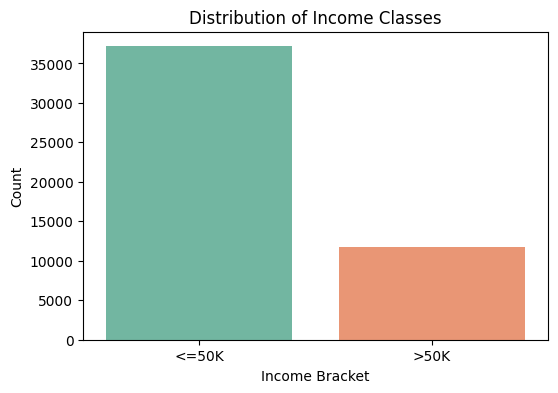

In [12]:

df['income'] = df['income'].str.rstrip('.')

print("\n--- Target Variable Distribution ---")
print(df['income'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=df, palette='Set2')
plt.title('Distribution of Income Classes')
plt.xlabel('Income Bracket')
plt.ylabel('Count')
plt.show()

In [13]:
print("\n--- Numerical Descriptive Statistics ---")
df.describe()




--- Numerical Descriptive Statistics ---


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


/tmp/ipykernel_844/3659983418.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y='age', data=df, ax=axes[1,1], palette='Pastel1')


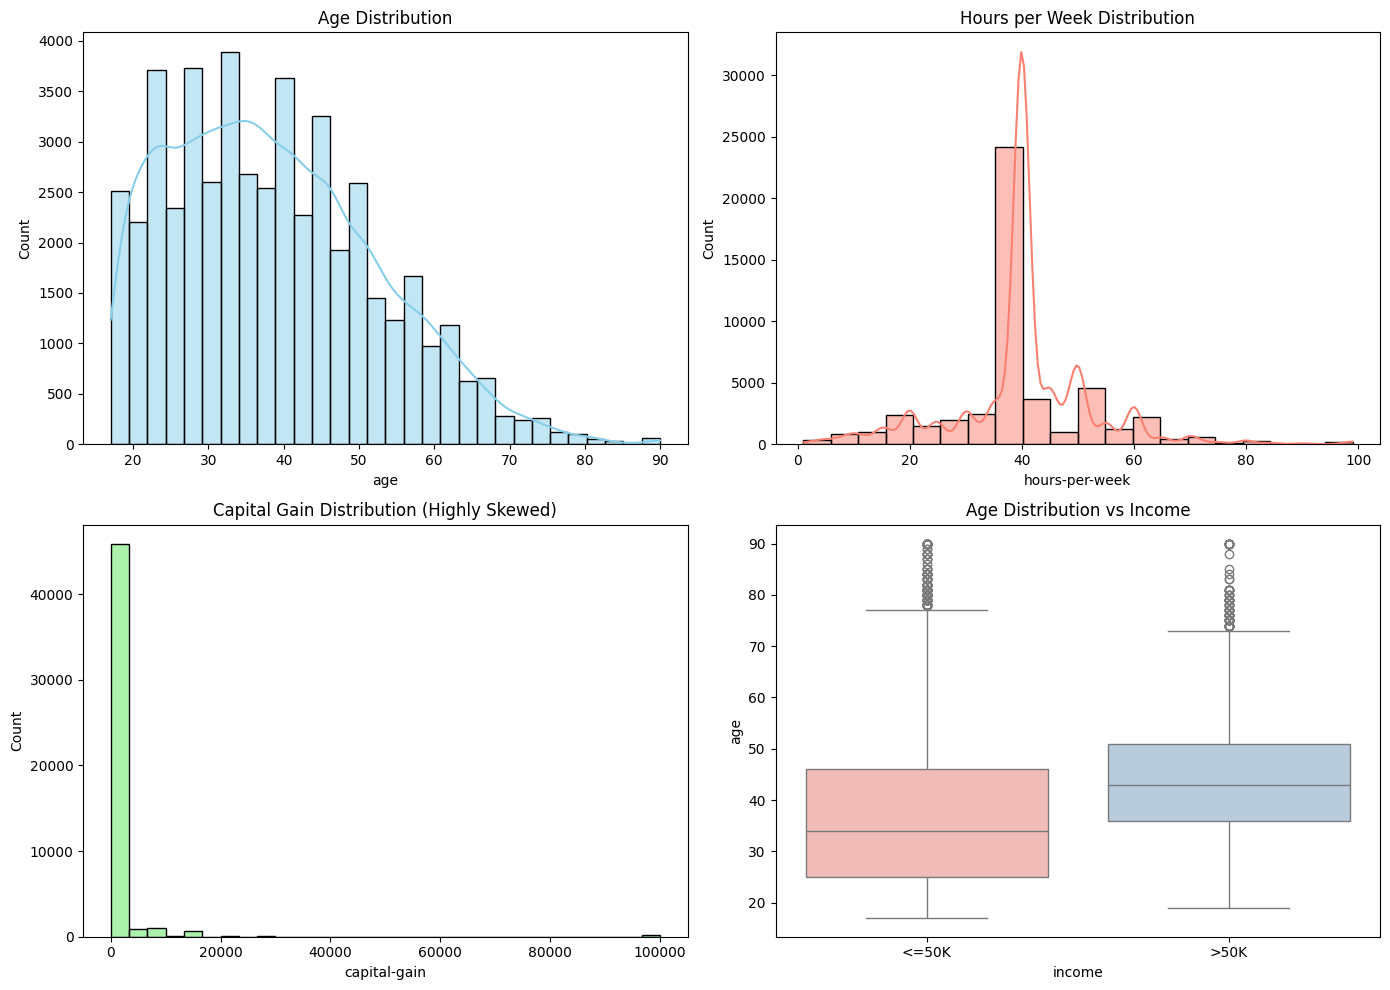

In [14]:
# Plot distributions of key numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['age'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution')

sns.histplot(df['hours-per-week'], bins=20, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Hours per Week Distribution')

# Capital gain is highly skewed; plot to see the tail
sns.histplot(df['capital-gain'], bins=30, kde=False, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Capital Gain Distribution (Highly Skewed)')

# Boxplot to examine outliers in age across income brackets
sns.boxplot(x='income', y='age', data=df, ax=axes[1,1], palette='Pastel1')
axes[1,1].set_title('Age Distribution vs Income')

plt.tight_layout()
plt.show()

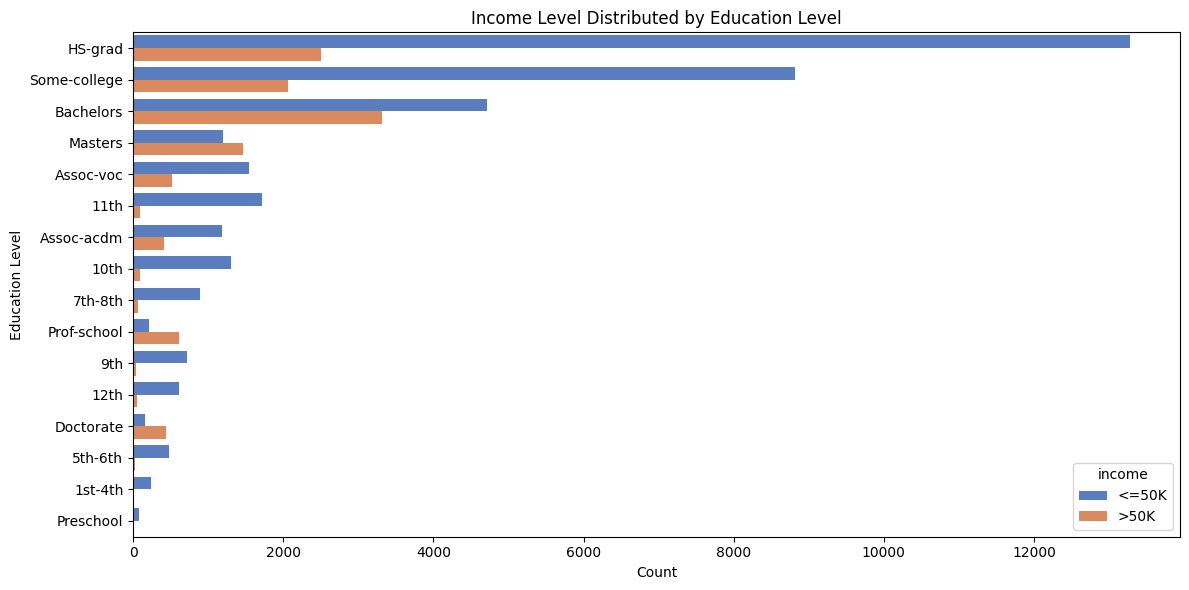

In [15]:
# Set up a plot to see how Education levels relate to Income
plt.figure(figsize=(12, 6))
sns.countplot(y='education', hue='income', data=df, order=df['education'].value_counts().index, palette='muted')
plt.title('Income Level Distributed by Education Level')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.tight_layout()
plt.show()

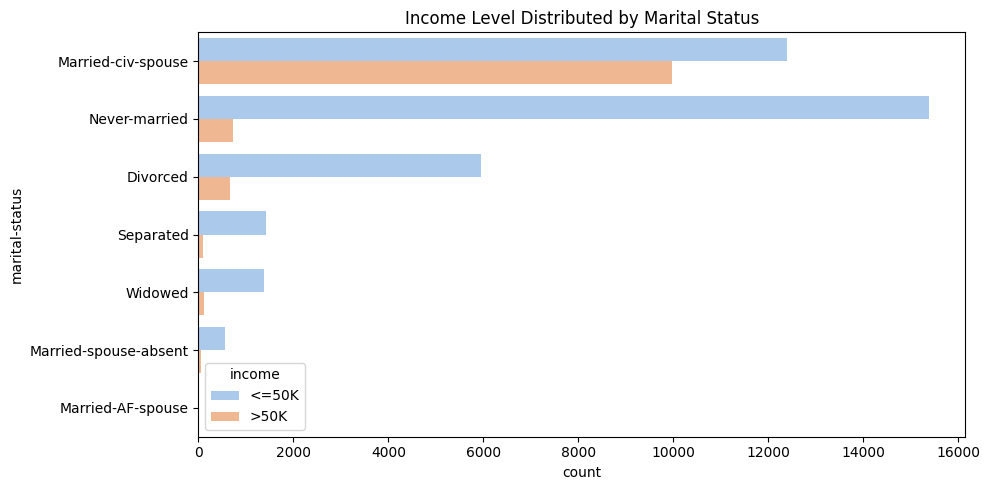

In [16]:
# Examine Marital Status vs Income
plt.figure(figsize=(10, 5))
sns.countplot(y='marital-status', hue='income', data=df, order=df['marital-status'].value_counts().index, palette='pastel')
plt.title('Income Level Distributed by Marital Status')
plt.tight_layout()
plt.show()

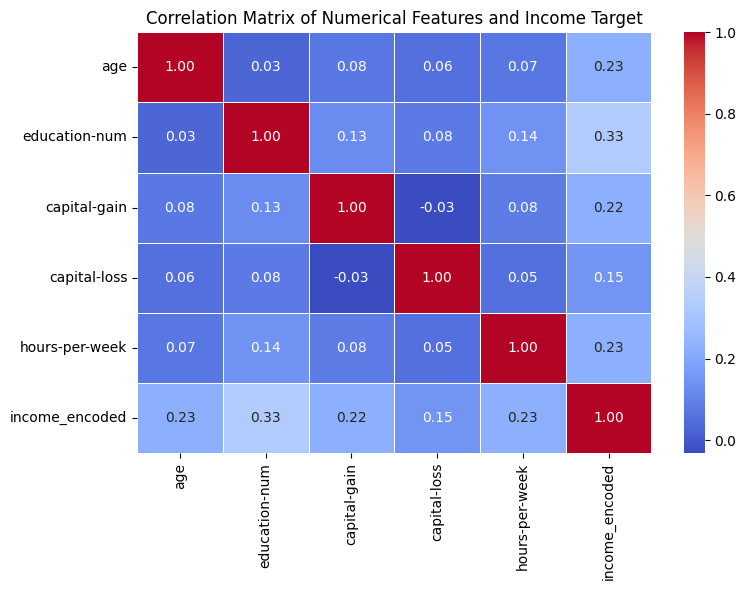

In [17]:
df['income_encoded'] = df['income'].map({'<=50K': 0, '>50K': 1})
numerical_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income_encoded']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features and Income Target')
plt.tight_layout()
plt.show()

Data Preprocessing

In [18]:
# Create a clean copy for data preparation steps
df_clean = df.copy()

# Replace the structural string placeholders with true NaNs
df_clean.replace('?', np.nan, inplace=True)

# List of columns containing missing attributes
missing_categorical_cols = ['workclass', 'occupation', 'native-country']

# Impute with an explicit categorical placeholder
for col in missing_categorical_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

print("Remaining Null Values per column:")
print(df_clean[missing_categorical_cols].isnull().sum())

Remaining Null Values per column:
workclass         0
occupation        0
native-country    0
dtype: int64


In [19]:
df_clean.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


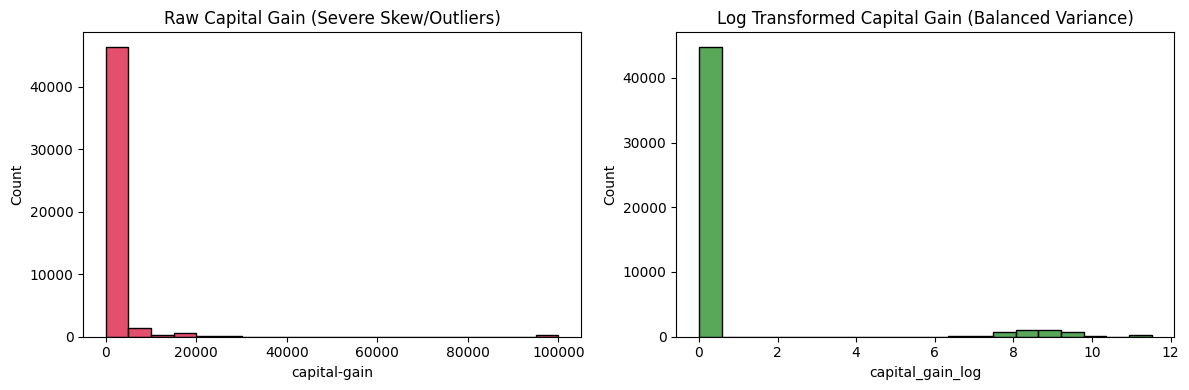

In [20]:
# 1. Derive a brand new consolidated variable: Net Capital Gain/Loss
# This reduces feature space while combining two interacting indicators
df_clean['capital_net'] = df_clean['capital-gain'] - df_clean['capital-loss']

# 2. Apply Logarithmic transformation (log1p safely handles 0 values by calculating log(x+1))
df_clean['capital_gain_log'] = np.log1p(df_clean['capital-gain'])
df_clean['capital_loss_log'] = np.log1p(df_clean['capital-loss'])
df_clean['capital_net_log'] = np.log1p(df_clean['capital_net'].clip(lower=0)) # Handle negative values safely

# 3. Visualise the structural improvement before and after transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['capital-gain'], bins=20, ax=axes[0], color='crimson', kde=False)
axes[0].set_title('Raw Capital Gain (Severe Skew/Outliers)')

sns.histplot(df_clean['capital_gain_log'], bins=20, ax=axes[1], color='forestgreen', kde=False)
axes[1].set_title('Log Transformed Capital Gain (Balanced Variance)')
plt.tight_layout()
plt.show()

In [21]:
# Clean the target variable text and convert it into binary classes
df_clean['income'] = df_clean['income'].astype(str).str.rstrip('.')
df_clean['income_encoded'] = df_clean['income'].map({'<=50K': 0, '>50K': 1})

y = df_clean['income_encoded']
df_features = df_clean.drop(columns=['income', 'income_encoded'])

In [22]:
# Drop redundant categorical text features that already have numeric tracking
df_features = df_features.drop(columns=['education'])
nominal_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

df_encoded = pd.get_dummies(df_features, columns=nominal_cols, drop_first=True)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
import os

# Define the directory path
output_dir = '/content/drive/MyDrive/COMM075/data'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Combine X_train and y_train into a single training DataFrame
df_train = pd.concat([X_train, y_train], axis=1)
df_train.to_csv(os.path.join(output_dir, 'train_data.csv'), index=False)
print('Training data saved to train_data.csv')

Training data saved to train_data.csv


In [25]:
import os

# Define the directory path
output_dir = '/content/drive/MyDrive/COMM075/data'

# Create the directory if it doesn't exist (ensure it exists before saving test data)
os.makedirs(output_dir, exist_ok=True)

# Combine X_test and y_test into a single testing DataFrame
df_test = pd.concat([X_test, y_test], axis=1)
df_test.to_csv(os.path.join(output_dir, 'test_data.csv'), index=False)
print('Testing data saved to test_data.csv')

Testing data saved to test_data.csv


In [26]:
from sklearn.preprocessing import StandardScaler

# Identify the continuous numeric columns that need scaling
continuous_cols = ['age', 'fnlwgt', 'education-num', 'hours-per-week',
                   'capital_gain_log', 'capital_loss_log', 'capital_net']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit on training data, then transform both training and testing datasets
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Data Preparation Complete!")
print(f"Training matrices shape: {X_train_scaled.shape}")
print(f"Testing matrices shape: {X_test_scaled.shape}")

Data Preparation Complete!
Training matrices shape: (39073, 89)
Testing matrices shape: (9769, 89)


### Final Training and Testing Data Preparation

In [27]:
X_train_scaled.head()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,capital_net,capital_gain_log,capital_loss_log,capital_net_log,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia
34495,-0.120090,0.029521,1.138210,0,0,-0.844835,-0.131595,-0.296054,-0.220527,0.0,...,False,False,False,False,False,False,True,False,False,False
18591,1.268245,0.252606,-0.804025,0,1651,-0.038454,-0.359996,-0.296054,4.466051,0.0,...,False,False,False,False,False,False,True,False,False,False
12562,1.049034,-0.597440,-0.415578,0,0,-0.441645,-0.131595,-0.296054,-0.220527,0.0,...,False,False,False,False,False,False,True,False,False,False
552,2.437369,0.145539,-1.192472,0,0,-0.038454,-0.131595,-0.296054,-0.220527,0.0,...,False,False,False,False,False,False,True,False,False,False
3479,0.537542,-0.789636,1.526657,0,0,-0.199731,-0.131595,-0.296054,-0.220527,0.0,...,False,False,False,False,False,False,True,False,False,False


In [28]:
cols_to_change = X_train_scaled.columns[10:]
X_train_scaled = X_train_scaled

In [29]:
y_train

,income_encoded
34495,0
18591,0
12562,0
552,0
3479,0
...,...
37700,1
16092,1
26498,1
20647,0


In [30]:
# Show all dataframe variables currently available

import pandas as pd

for var_name in dir():
    obj = globals()[var_name]

    if isinstance(obj, pd.DataFrame):
        print(var_name, obj.shape)

X (48842, 14)
X_test (9769, 89)
X_test_scaled (9769, 89)
X_train (39073, 89)
X_train_scaled (39073, 89)
_13 (8, 6)
_27 (5, 89)
_9 (5, 15)
__ (5, 89)
corr_matrix (6, 6)
df (48842, 16)
df_clean (48842, 20)
df_encoded (48842, 89)
df_features (48842, 17)
df_test (9769, 90)
df_train (39073, 90)


In [31]:
# CLEAN TRAIN + TEST DATASETS

# Combine X_train_scaled and y_train into a single training DataFrame
train_df = pd.concat([X_train_scaled, y_train], axis=1)

# Combine X_test_scaled and y_test into a single testing DataFrame
test_df = pd.concat([X_test_scaled, y_test], axis=1)

# Convert boolean values to 0 and 1
train_df = train_df.applymap(
    lambda x: 1 if x is True else (0 if x is False else x)
)

test_df = test_df.applymap(
    lambda x: 1 if x is True else (0 if x is False else x)
)



train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

/tmp/ipykernel_844/2946980694.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_df = train_df.applymap(
/tmp/ipykernel_844/2946980694.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  test_df = test_df.applymap(


In [32]:
# VERIFY TRAIN DATASET


print("TRAIN DATASET")
print(train_df.head())

print("\nTotal NaN values (Train):",
      train_df.isnull().sum().sum())

print("\nTrain Data Types:\n",
      train_df.dtypes.value_counts())

TRAIN DATASET
        age    fnlwgt  education-num  capital-gain  capital-loss  \
0 -0.120090  0.029521       1.138210             0             0   
1  1.268245  0.252606      -0.804025             0          1651   
2  1.049034 -0.597440      -0.415578             0             0   
3  2.437369  0.145539      -1.192472             0             0   
4  0.537542 -0.789636       1.526657             0             0   

   hours-per-week  capital_net  capital_gain_log  capital_loss_log  \
0       -0.844835    -0.131595         -0.296054         -0.220527   
1       -0.038454    -0.359996         -0.296054          4.466051   
2       -0.441645    -0.131595         -0.296054         -0.220527   
3       -0.038454    -0.131595         -0.296054         -0.220527   
4       -0.199731    -0.131595         -0.296054         -0.220527   

   capital_net_log  ...  native-country_Scotland  native-country_South  \
0              0.0  ...                        0                     0   
1       

In [33]:

# VERIFY TEST DATASET


print("\n\nTEST DATASET")
print(test_df.head())

print("\nTotal NaN values (Test):",
      test_df.isnull().sum().sum())

print("\nTest Data Types:\n",
      test_df.dtypes.value_counts())



TEST DATASET
        age    fnlwgt  education-num  capital-gain  capital-loss  \
0 -0.631582  1.782563      -0.415578             0             0   
1  1.122104 -1.271682       0.749763             0             0   
2 -1.289214  0.134949      -0.027131             0             0   
3 -0.266231  1.106283      -0.415578          2885             0   
4  0.245261 -0.653993      -0.027131             0             0   

   hours-per-week  capital_net  capital_gain_log  capital_loss_log  \
0       -0.038454    -0.131595         -0.296054         -0.220527   
1       -0.119092    -0.131595         -0.296054         -0.220527   
2       -0.441645    -0.131595         -0.296054         -0.220527   
3       -0.038454     0.267520          2.983869         -0.220527   
4        0.364736    -0.131595         -0.296054         -0.220527   

   capital_net_log  ...  native-country_Scotland  native-country_South  \
0         0.000000  ...                        0                     0   
1      

In [34]:
# SAVE CLEANED DATASETS


train_file_name = "adult_income_train_preprocessed_cleaned.csv"
test_file_name = "adult_income_test_preprocessed_cleaned.csv"

train_df.to_csv(train_file_name, index=False)
test_df.to_csv(test_file_name, index=False)

print("CLEANED DATASETS SAVED SUCCESSFULLY!")


print(f"\nTrain File Saved As: {train_file_name}")
print(f"Test File Saved As : {test_file_name}")

CLEANED DATASETS SAVED SUCCESSFULLY!

Train File Saved As: adult_income_train_preprocessed_cleaned.csv
Test File Saved As : adult_income_test_preprocessed_cleaned.csv


In [35]:
import pandas as pd

train_df = pd.read_csv("adult_income_train_preprocessed_cleaned.csv")
test_df = pd.read_csv("adult_income_test_preprocessed_cleaned.csv")

In [36]:
test_df.head(30)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,capital_net,capital_gain_log,capital_loss_log,capital_net_log,...,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia,income_encoded
0,-0.631582,1.782563,-0.415578,0,0,-0.038454,-0.131595,-0.296054,-0.220527,0.000000,...,0,0,0,0,0,1,0,0,0,0
1,1.122104,-1.271682,0.749763,0,0,-0.119092,-0.131595,-0.296054,-0.220527,0.000000,...,0,0,0,0,0,1,0,0,0,0
2,-1.289214,0.134949,-0.027131,0,0,-0.441645,-0.131595,-0.296054,-0.220527,0.000000,...,0,0,0,0,0,1,0,0,0,0
3,-0.266231,1.106283,-0.415578,2885,0,-0.038454,0.267520,2.983869,-0.220527,7.967627,...,0,0,0,0,0,1,0,0,0,0
4,0.245261,-0.653993,-0.027131,0,0,0.364736,-0.131595,-0.296054,-0.220527,0.000000,...,0,0,0,0,0,1,0,0,0,1
5,-0.923863,0.048473,-0.415578,0,0,-0.038454,-0.131595,-0.296054,-0.220527,0.000000,...,0,0,0,0,0,1,0,0,0,0
6,0.829823,1.249862,1.915104,0,0,2.783878,-0.131595,-0.296054,-0.220527,0.000000,...,0,0,0,0,0,1,0,0,0,1
7,-0.339301,-0.796187,-0.027131,0,0,-0.038454,-0.131595,-0.296054,-0.220527,0.000000,...,0,0,0,0,0,1,0,0,0,0
8,-0.704652,0.103681,-0.415578,0,0,-0.038454,-0.131595,-0.296054,-0.220527,0.000000,...,0,0,0,0,0,1,0,0,0,1
9,-0.266231,-1.218048,-0.415578,0,0,-0.441645,-0.131595,-0.296054,-0.220527,0.000000,...,0,0,0,0,0,1,0,0,0,0


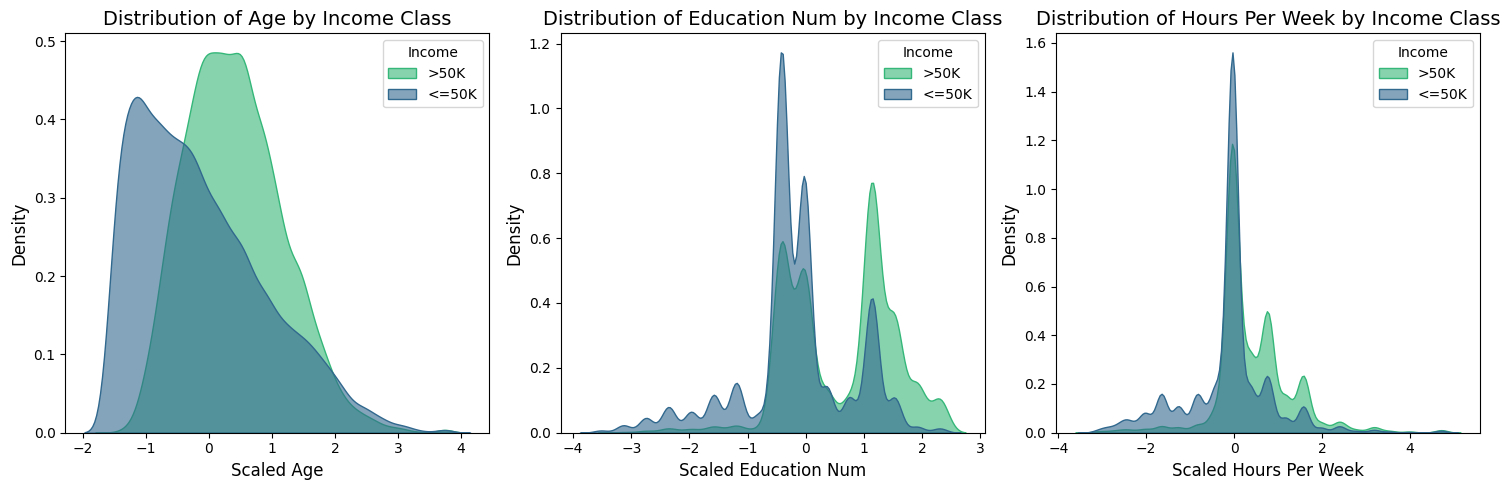


These plots demonstrate the significant overlap between the two income classes (<=50K and >50K) across these key numerical features. For example, individuals earning >50K are generally older and have more education, but there's a large segment of the <=50K population that shares similar characteristics. This high degree of overlap makes it challenging for simple linear decision boundaries to perfectly separate the classes, highlighting the need for more complex, non-linear models to capture the nuanced relationships in the data.


In [46]:


features_to_visualize = ['age', 'education-num', 'hours-per-week']


fig, axes = plt.subplots(1, len(features_to_visualize), figsize=(5 * len(features_to_visualize), 5))

for i, feature in enumerate(features_to_visualize):
    sns.kdeplot(
        data=train_df,
        x=feature,
        hue='income_encoded',
        fill=True,
        common_norm=False,
        palette='viridis',
        ax=axes[i],
        alpha=0.6
    )
    axes[i].set_title(f'Distribution of {feature.replace("-", " ").title()} by Income Class', fontsize=14)
    axes[i].set_xlabel(f'Scaled {feature.replace("-", " ").title()}', fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)
    axes[i].legend(title='Income', labels=['>50K', '<=50K'])

plt.tight_layout()
plt.show()

print("\nThese plots demonstrate the significant overlap between the two income classes (<=50K and >50K) across these key numerical features. For example, individuals earning >50K are generally older and have more education, but there's a large segment of the <=50K population that shares similar characteristics. This high degree of overlap makes it challenging for simple linear decision boundaries to perfectly separate the classes, highlighting the need for more complex, non-linear models to capture the nuanced relationships in the data.")

Each team member will run their respective optimized model and output its corresponding confusion matrix. Performance will be evaluated based on Accuracy, Precision, Recall, F1-score, and ROC-AUC. Individual ROC curves do not need to be visualized at this stage, as they will be consolidated into a single composite ROC curve and model comparison plot. Given the strict 11-page limit for this paper, we must minimize individual visualizations to conserve space.